In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('application_train.csv')


In [8]:
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [10]:
df['TARGET'].value_counts()
df['TARGET'].value_counts(normalize=True) * 100

0    91.927118
1     8.072882
Name: TARGET, dtype: float64

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0].head(20))

                          Missing  Percentage
COMMONAREA_MEDI            214865   69.872297
COMMONAREA_AVG             214865   69.872297
COMMONAREA_MODE            214865   69.872297
NONLIVINGAPARTMENTS_MODE   213514   69.432963
NONLIVINGAPARTMENTS_AVG    213514   69.432963
NONLIVINGAPARTMENTS_MEDI   213514   69.432963
FONDKAPREMONT_MODE         210295   68.386172
LIVINGAPARTMENTS_MODE      210199   68.354953
LIVINGAPARTMENTS_AVG       210199   68.354953
LIVINGAPARTMENTS_MEDI      210199   68.354953
FLOORSMIN_AVG              208642   67.848630
FLOORSMIN_MODE             208642   67.848630
FLOORSMIN_MEDI             208642   67.848630
YEARS_BUILD_MEDI           204488   66.497784
YEARS_BUILD_MODE           204488   66.497784
YEARS_BUILD_AVG            204488   66.497784
OWN_CAR_AGE                202929   65.990810
LANDAREA_MEDI              182590   59.376738
LANDAREA_MODE              182590   59.376738
LANDAREA_AVG               182590   59.376738


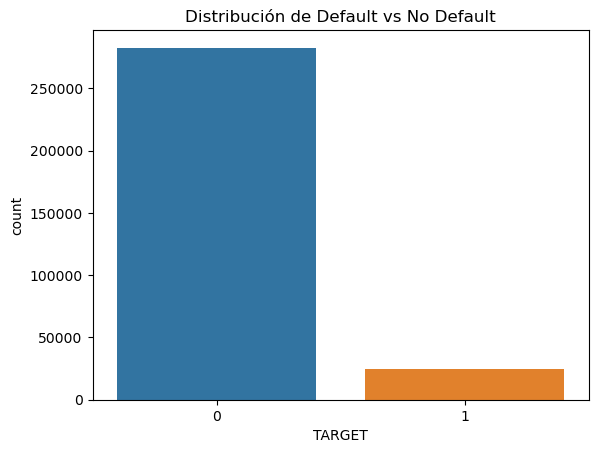

In [12]:
sns.countplot(x='TARGET', data=df)
plt.title('Distribución de Default vs No Default')
plt.show()

In [16]:
threshold = 0.4
df = df[df.columns[df.isnull().mean() < threshold]]
print(f"Colums left: {df.shape[1]}")

Colums left: 73


In [17]:
target_counts = df['TARGET'].value_counts(normalize=True) * 100
print(target_counts)

0    91.927118
1     8.072882
Name: TARGET, dtype: float64


In [18]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Numeric columns: 61
Categorical columns: 12


In [19]:
# Numeric: fill with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical: fill with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify no nulls left
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Remaining nulls: 0


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding complete!")
df.head()

Encoding complete!


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (307511, 72)
Target: (307511,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (246008, 72)
Test set: (61503, 72)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

ROC-AUC Score: 0.7434


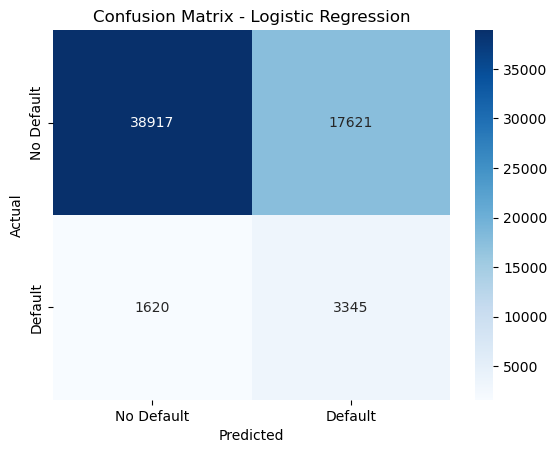

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC Score (the most important metric for credit risk)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # uses all your CPU cores, faster
)

rf.fit(X_train, y_train)
print("Random Forest trained!")

Random Forest trained!


In [26]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC Score - Random Forest: {roc_auc_rf:.4f}")

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.44      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503

ROC-AUC Score - Random Forest: 0.7226


In [28]:
# Run this in a separate cell first
!pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 640.0 kB/s eta 0:02:39
   ---------------------------------------- 0.1/101.7 MB 812.7 kB/s eta 0:02:06
   ---------------------------------------- 0.1/101.7 MB 744.7 kB/s eta 0:02:17
   ---------------------------------------- 0.1/101.7 MB 653.6 kB/s eta 0:02:36
   ---------------------------------------- 0.1/101.7 MB 554.9 kB/s eta 0:03:04
   ---------------------------------------- 0.1/101.7 MB 554.9 kB/s eta 0:03:04
   ---------------------------------------- 0.1/101.7 MB 554.9 kB/s eta 0:03:04
   ---------------------------------------- 0.1/101.7 MB 554.9 kB/s eta 0:03:04
   ---------------------------------------- 0.1/101.7 MB 355.0 kB/s eta 0:04:47
   -

In [29]:
import xgboost as xgb

# Calculate scale for imbalance
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale weight: {scale:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,  # handles the 8% imbalance
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained!")

Scale weight: 11.39
XGBoost trained!


In [30]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.3).astype(int)  # tuned threshold

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score - XGBoost: {roc_auc_score(y_test, y_prob_xgb):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.36      0.52     56538
           1       0.11      0.91      0.20      4965

    accuracy                           0.40     61503
   macro avg       0.54      0.63      0.36     61503
weighted avg       0.91      0.40      0.50     61503

ROC-AUC Score - XGBoost: 0.7533


In [31]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0
best_f1 = 0

for thresh in thresholds:
    y_pred_temp = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}")
print(f"Best F1 score: {best_f1:.4f}")

Best threshold: 0.65
Best F1 score: 0.3039


In [32]:
y_pred_xgb_best = (y_prob_xgb >= best_thresh).astype(int)

print(f"XGBoost - Optimized Threshold ({best_thresh:.2f}):")
print(classification_report(y_test, y_pred_xgb_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost - Optimized Threshold (0.65):
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.24      0.42      0.30      4965

    accuracy                           0.85     61503
   macro avg       0.59      0.65      0.61     61503
weighted avg       0.89      0.85      0.86     61503

ROC-AUC: 0.7533


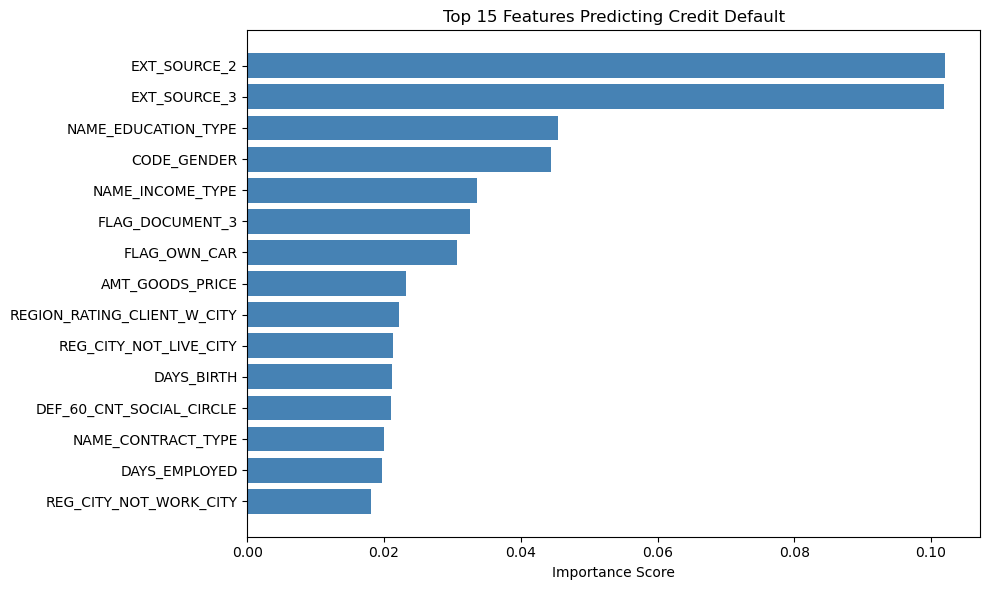

                        feature  importance
39                 EXT_SOURCE_2    0.102055
40                 EXT_SOURCE_3    0.101871
12          NAME_EDUCATION_TYPE    0.045385
2                   CODE_GENDER    0.044441
11             NAME_INCOME_TYPE    0.033649
47              FLAG_DOCUMENT_3    0.032523
3                  FLAG_OWN_CAR    0.030593
9               AMT_GOODS_PRICE    0.023177
29  REGION_RATING_CLIENT_W_CITY    0.022184
35       REG_CITY_NOT_LIVE_CITY    0.021281
16                   DAYS_BIRTH    0.021206
44     DEF_60_CNT_SOCIAL_CIRCLE    0.020967
1            NAME_CONTRACT_TYPE    0.019981
17                DAYS_EMPLOYED    0.019639
36       REG_CITY_NOT_WORK_CITY    0.018119


In [33]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 most important features
top15 = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
plt.title('Top 15 Features Predicting Credit Default')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(top15)

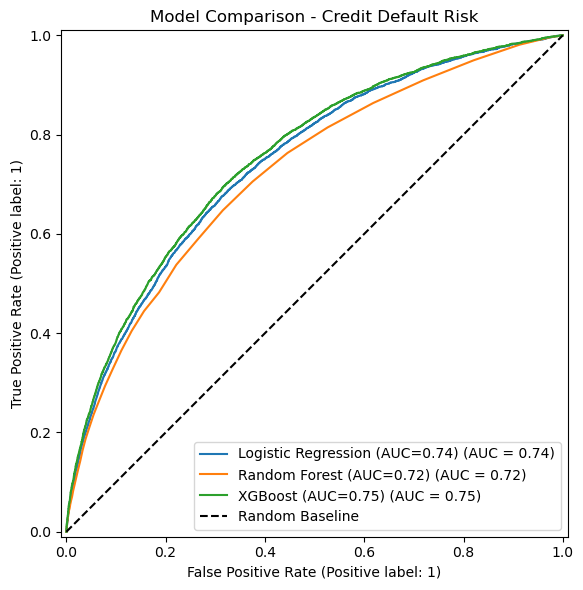

In [43]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob, 
                                  name=f"Logistic Regression (AUC=0.74)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, 
                                  name=f"Random Forest (AUC=0.72)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, 
                                  name=f"XGBoost (AUC=0.75)", ax=ax)

plt.plot([0,1], [0,1], 'k--', label='Random Baseline')
plt.title('Model Comparison - Credit Default Risk')
plt.legend()
plt.tight_layout()
plt.show()